In [ ]:
# Imports y carga de datos

%pip install pandas numpy matplotlib seaborn nltk
import pandas as pd
import numpy as np
import re
import string
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

print("Librerías cargadas correctamente")

Note: you may need to restart the kernel to use updated packages.
Librerías cargadas correctamente


In [92]:
# Cargar dataset

RUTA_KJV = "../data/t_kjv.csv"
RUTA_KEY = "../data/key_english.csv"
df_bible = pd.read_csv(RUTA_KJV, header=0)
df_bible.columns = ["id", "book_id", "chapter", "verse", "text"]

df_keys = pd.read_csv(RUTA_KEY, header=0)
df_keys.columns = ["book_id", "book_name", "testament", "genre_id"]

df = df_bible.merge(df_keys[["book_id", "book_name", "testament"]], on="book_id", how="left")

print(f" Dataset cargado: {len(df):,} versículos")
print(f"   Libros: {df['book_name'].nunique()}")
print(f"   Antiguo Testamento: {(df['testament']=='OT').sum():,} versículos")
print(f"   Nuevo Testamento:   {(df['testament']=='NT').sum():,} versículos")
df.head(3)

 Dataset cargado: 31,103 versículos
   Libros: 66
   Antiguo Testamento: 23,145 versículos
   Nuevo Testamento:   7,958 versículos


,id,book_id,chapter,verse,text,book_name,testament
0,1001001,1,1,1,In the beginning God created the heaven and th...,Genesis,OT
1,1001002,1,1,2,"And the earth was without form, and void; and ...",Genesis,OT
2,1001003,1,1,3,"And God said, Let there be light: and there wa...",Genesis,OT


In [ ]:
# Clase de Preprocesamiento

class BiblePreprocessor:
    """
    Pipeline de preprocesamiento textual para el corpus bíblico.
    Aplica limpieza, tokenización, eliminación de stopwords
    y construcción de vocabulario y frecuencias.
    """
    def __init__(self, language='english'):
        self.language = language
        self.stop_words = set(stopwords.words(language))
        self.vocabulary = {}        
        self.word_freq = Counter()  
        self.is_fitted = False

    def _clean_text(self, text: str) -> str:
        """Minúsculas, sin puntuación, sin números ni caracteres especiales."""
        text = text.lower()
        text = re.sub(r'\d+', '', text)                        # eliminar números
        text = text.translate(str.maketrans('', '', string.punctuation))  # sin puntuación
        text = re.sub(r'[^a-z\s]', '', text)                  # solo letras
        text = re.sub(r'\s+', ' ', text).strip()              # espacios extra
        return text

    def _tokenize(self, text: str) -> list:
        """Tokenización simple por espacios."""
        return text.split()

    def _remove_stopwords(self, tokens: list) -> list:
        """Elimina palabras vacías."""
        return [t for t in tokens if t not in self.stop_words]

    def preprocess(self, text: str, remove_sw=True) -> list:
        """Pipeline completo: limpieza → tokenización → (stopwords)."""
        cleaned = self._clean_text(text)
        tokens  = self._tokenize(cleaned)
        if remove_sw:
            tokens = self._remove_stopwords(tokens)
        return tokens

    def fit(self, texts: pd.Series):
        """Construye vocabulario y frecuencias sobre toda la serie de textos."""
        all_tokens = []
        for text in texts:
            tokens = self.preprocess(text)
            all_tokens.extend(tokens)

        self.word_freq = Counter(all_tokens)
        self.vocabulary = {word: idx for idx, (word, _) in
                           enumerate(self.word_freq.most_common())}
        self.is_fitted = True
        print(f" Vocabulario construido: {len(self.vocabulary):,} palabras únicas")
        print(f"   Top 10: {self.word_freq.most_common(10)}")
        return self

    def transform(self, texts: pd.Series) -> pd.Series:
        """Aplica el pipeline a una serie y devuelve tokens por versículo."""
        return texts.apply(self.preprocess)

preprocessor = BiblePreprocessor()
preprocessor.fit(df['text'])

df['tokens'] = preprocessor.transform(df['text'])
df['token_count'] = df['tokens'].apply(len)

print(f"\n Tokens generados. Ejemplo:")
print(df[['book_name','text','tokens']].head(2).to_string())

 Vocabulario construido: 12,603 palabras únicas
   Top 10: [('shall', 9838), ('unto', 8997), ('lord', 7830), ('thou', 5474), ('thy', 4600), ('god', 4443), ('said', 3999), ('ye', 3982), ('thee', 3826), ('upon', 2748)]

 Tokens generados. Ejemplo:
  book_name                                                                                                                                            text                                                                                            tokens
0   Genesis                                                                                          In the beginning God created the heaven and the earth.                                                          [beginning, god, created, heaven, earth]
1   Genesis  And the earth was without form, and void; and darkness was upon the face of the deep. And the Spirit of God moved upon the face of the waters.  [earth, without, form, void, darkness, upon, face, deep, spirit, god, moved, upon, face, 

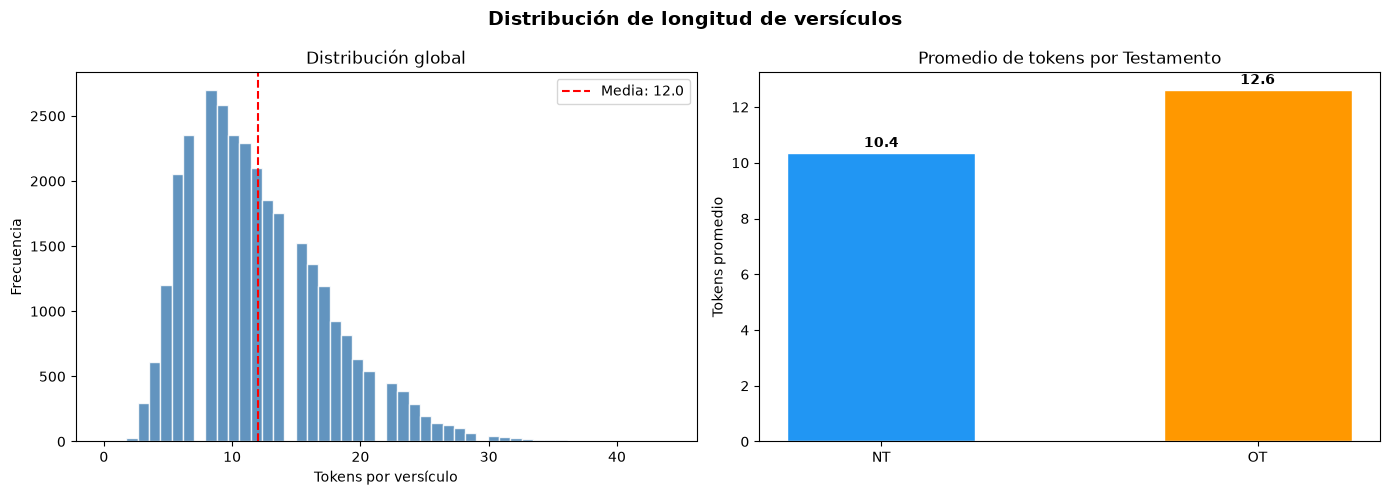

 Visualización 1 guardada


In [94]:
# Visualización 1: Longitud de versículos

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribución de longitud de versículos", fontsize=14, fontweight='bold')

# Histograma de tokens por versículo
axes[0].hist(df['token_count'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel("Tokens por versículo")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución global")
axes[0].axvline(df['token_count'].mean(), color='red', linestyle='--', label=f"Media: {df['token_count'].mean():.1f}")
axes[0].legend()

# Promedio por testamento
avg_by_test = df.groupby('testament')['token_count'].mean().reset_index()
axes[1].bar(avg_by_test['testament'], avg_by_test['token_count'], 
            color=['#2196F3','#FF9800'], edgecolor='white', width=0.5)
axes[1].set_title("Promedio de tokens por Testamento")
axes[1].set_ylabel("Tokens promedio")
for i, v in enumerate(avg_by_test['token_count']):
    axes[1].text(i, v + 0.2, f"{v:.1f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("../outputs/viz1_longitud_versiculos.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Visualización 1 guardada")

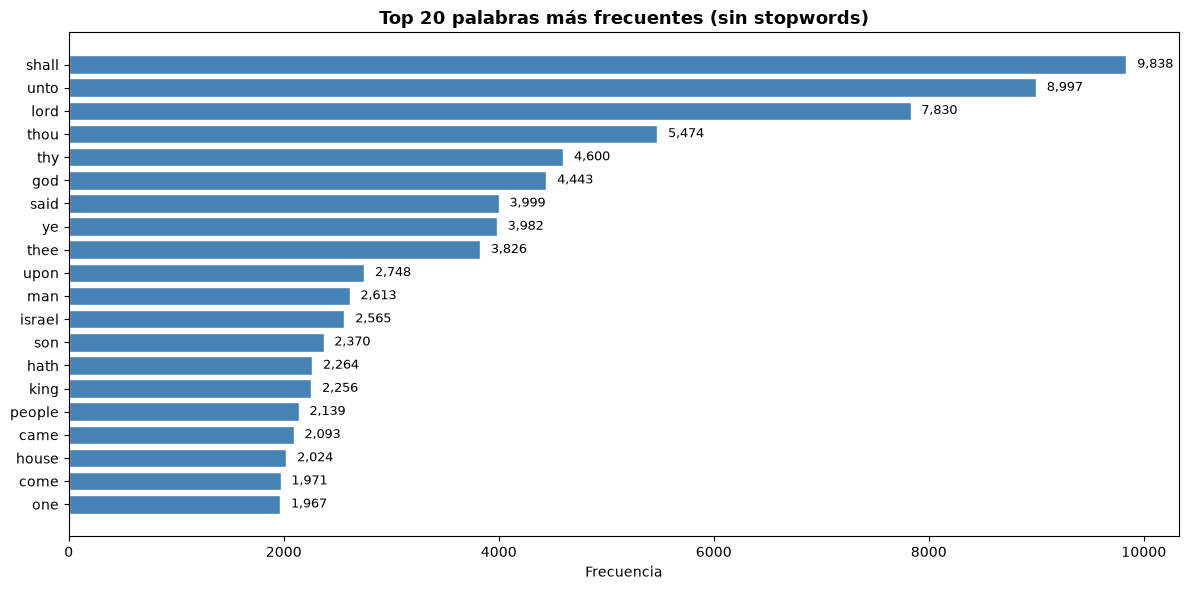

 Visualización 2 guardada


In [95]:
# Visualización 2: Top 20 palabras más frecuentes

top_words = preprocessor.word_freq.most_common(20)
words, freqs = zip(*top_words)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(words[::-1], freqs[::-1], color='steelblue', edgecolor='white')
ax.set_title("Top 20 palabras más frecuentes (sin stopwords)", fontsize=13, fontweight='bold')
ax.set_xlabel("Frecuencia")

# Etiquetas en las barras
for bar, freq in zip(bars, freqs[::-1]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{freq:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/viz2_top_palabras.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Visualización 2 guardada")

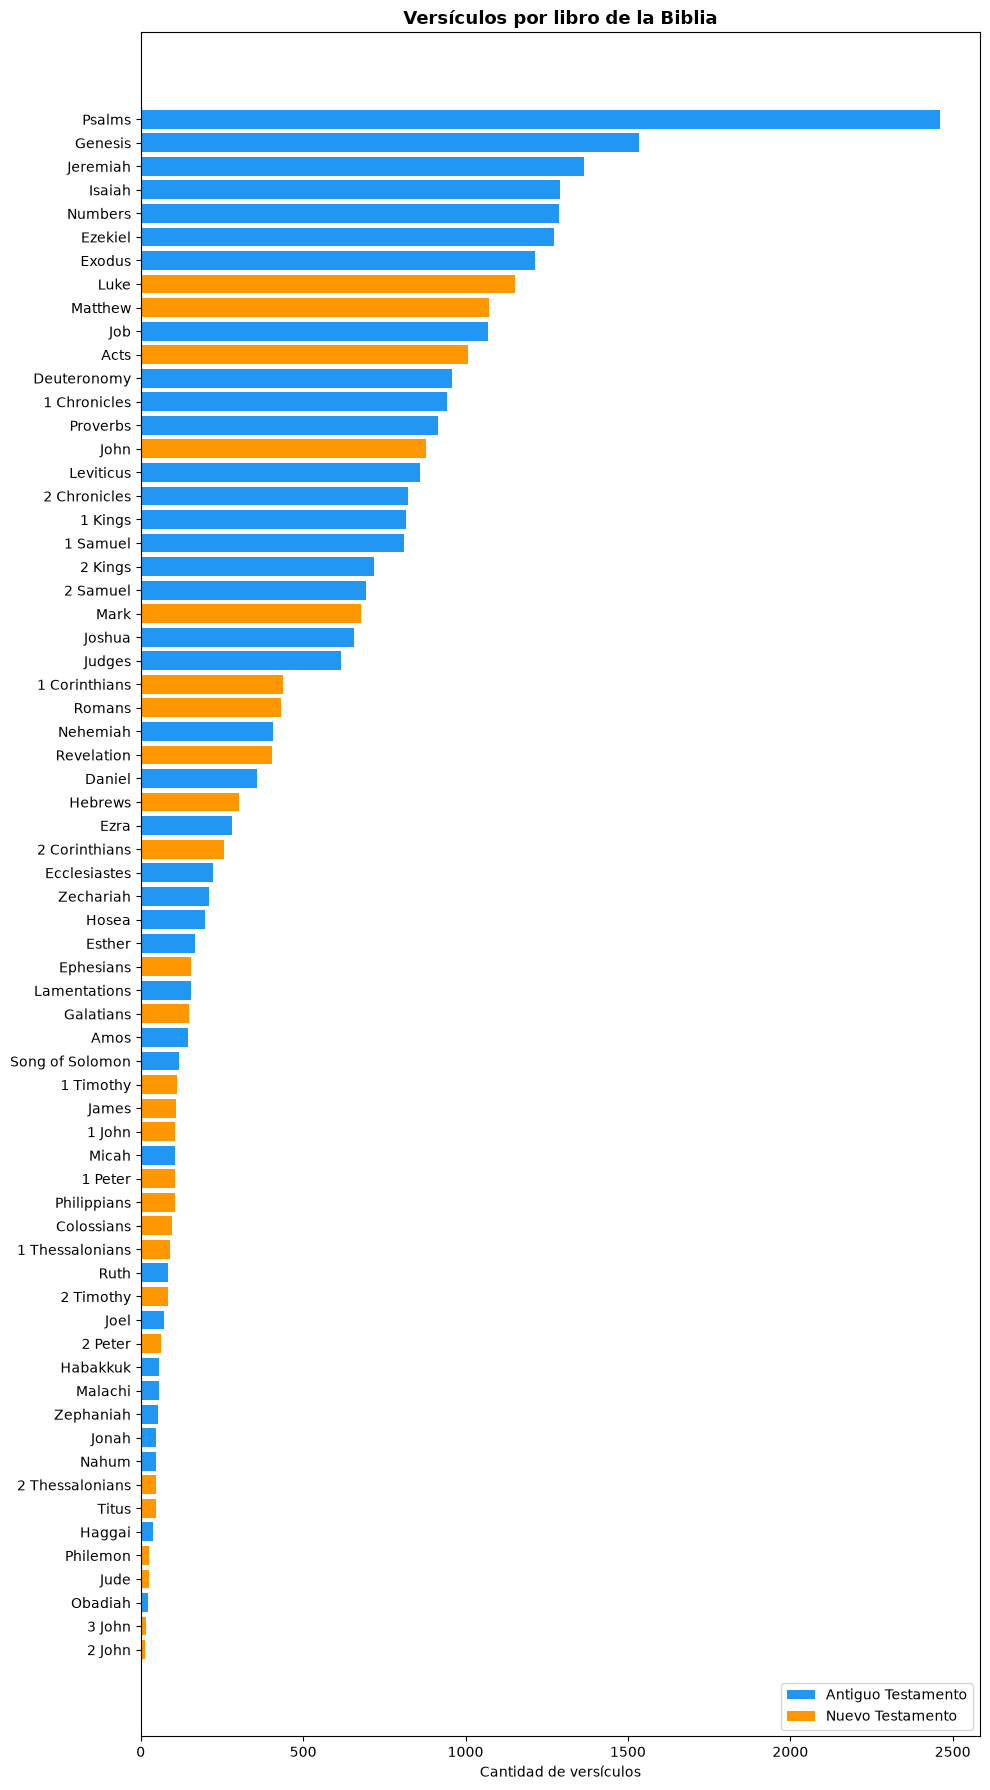

 Visualización 3 guardada


In [96]:
# Visualización 3: Cantidad de versículos por libro

verses_per_book = df.groupby(['book_name','testament'])['verse'].count().reset_index()
verses_per_book.columns = ['book_name','testament','verse_count']
verses_per_book = verses_per_book.sort_values('verse_count', ascending=True)

colors = ['#2196F3' if t == 'OT' else '#FF9800' for t in verses_per_book['testament']]

fig, ax = plt.subplots(figsize=(10, 18))
ax.barh(verses_per_book['book_name'], verses_per_book['verse_count'], color=colors)
ax.set_title("Versículos por libro de la Biblia", fontsize=13, fontweight='bold')
ax.set_xlabel("Cantidad de versículos")

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2196F3', label='Antiguo Testamento'),
                   Patch(facecolor='#FF9800', label='Nuevo Testamento')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig("../outputs/viz3_versiculos_por_libro.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Visualización 3 guardada")

 Calculando TF-IDF por libro 


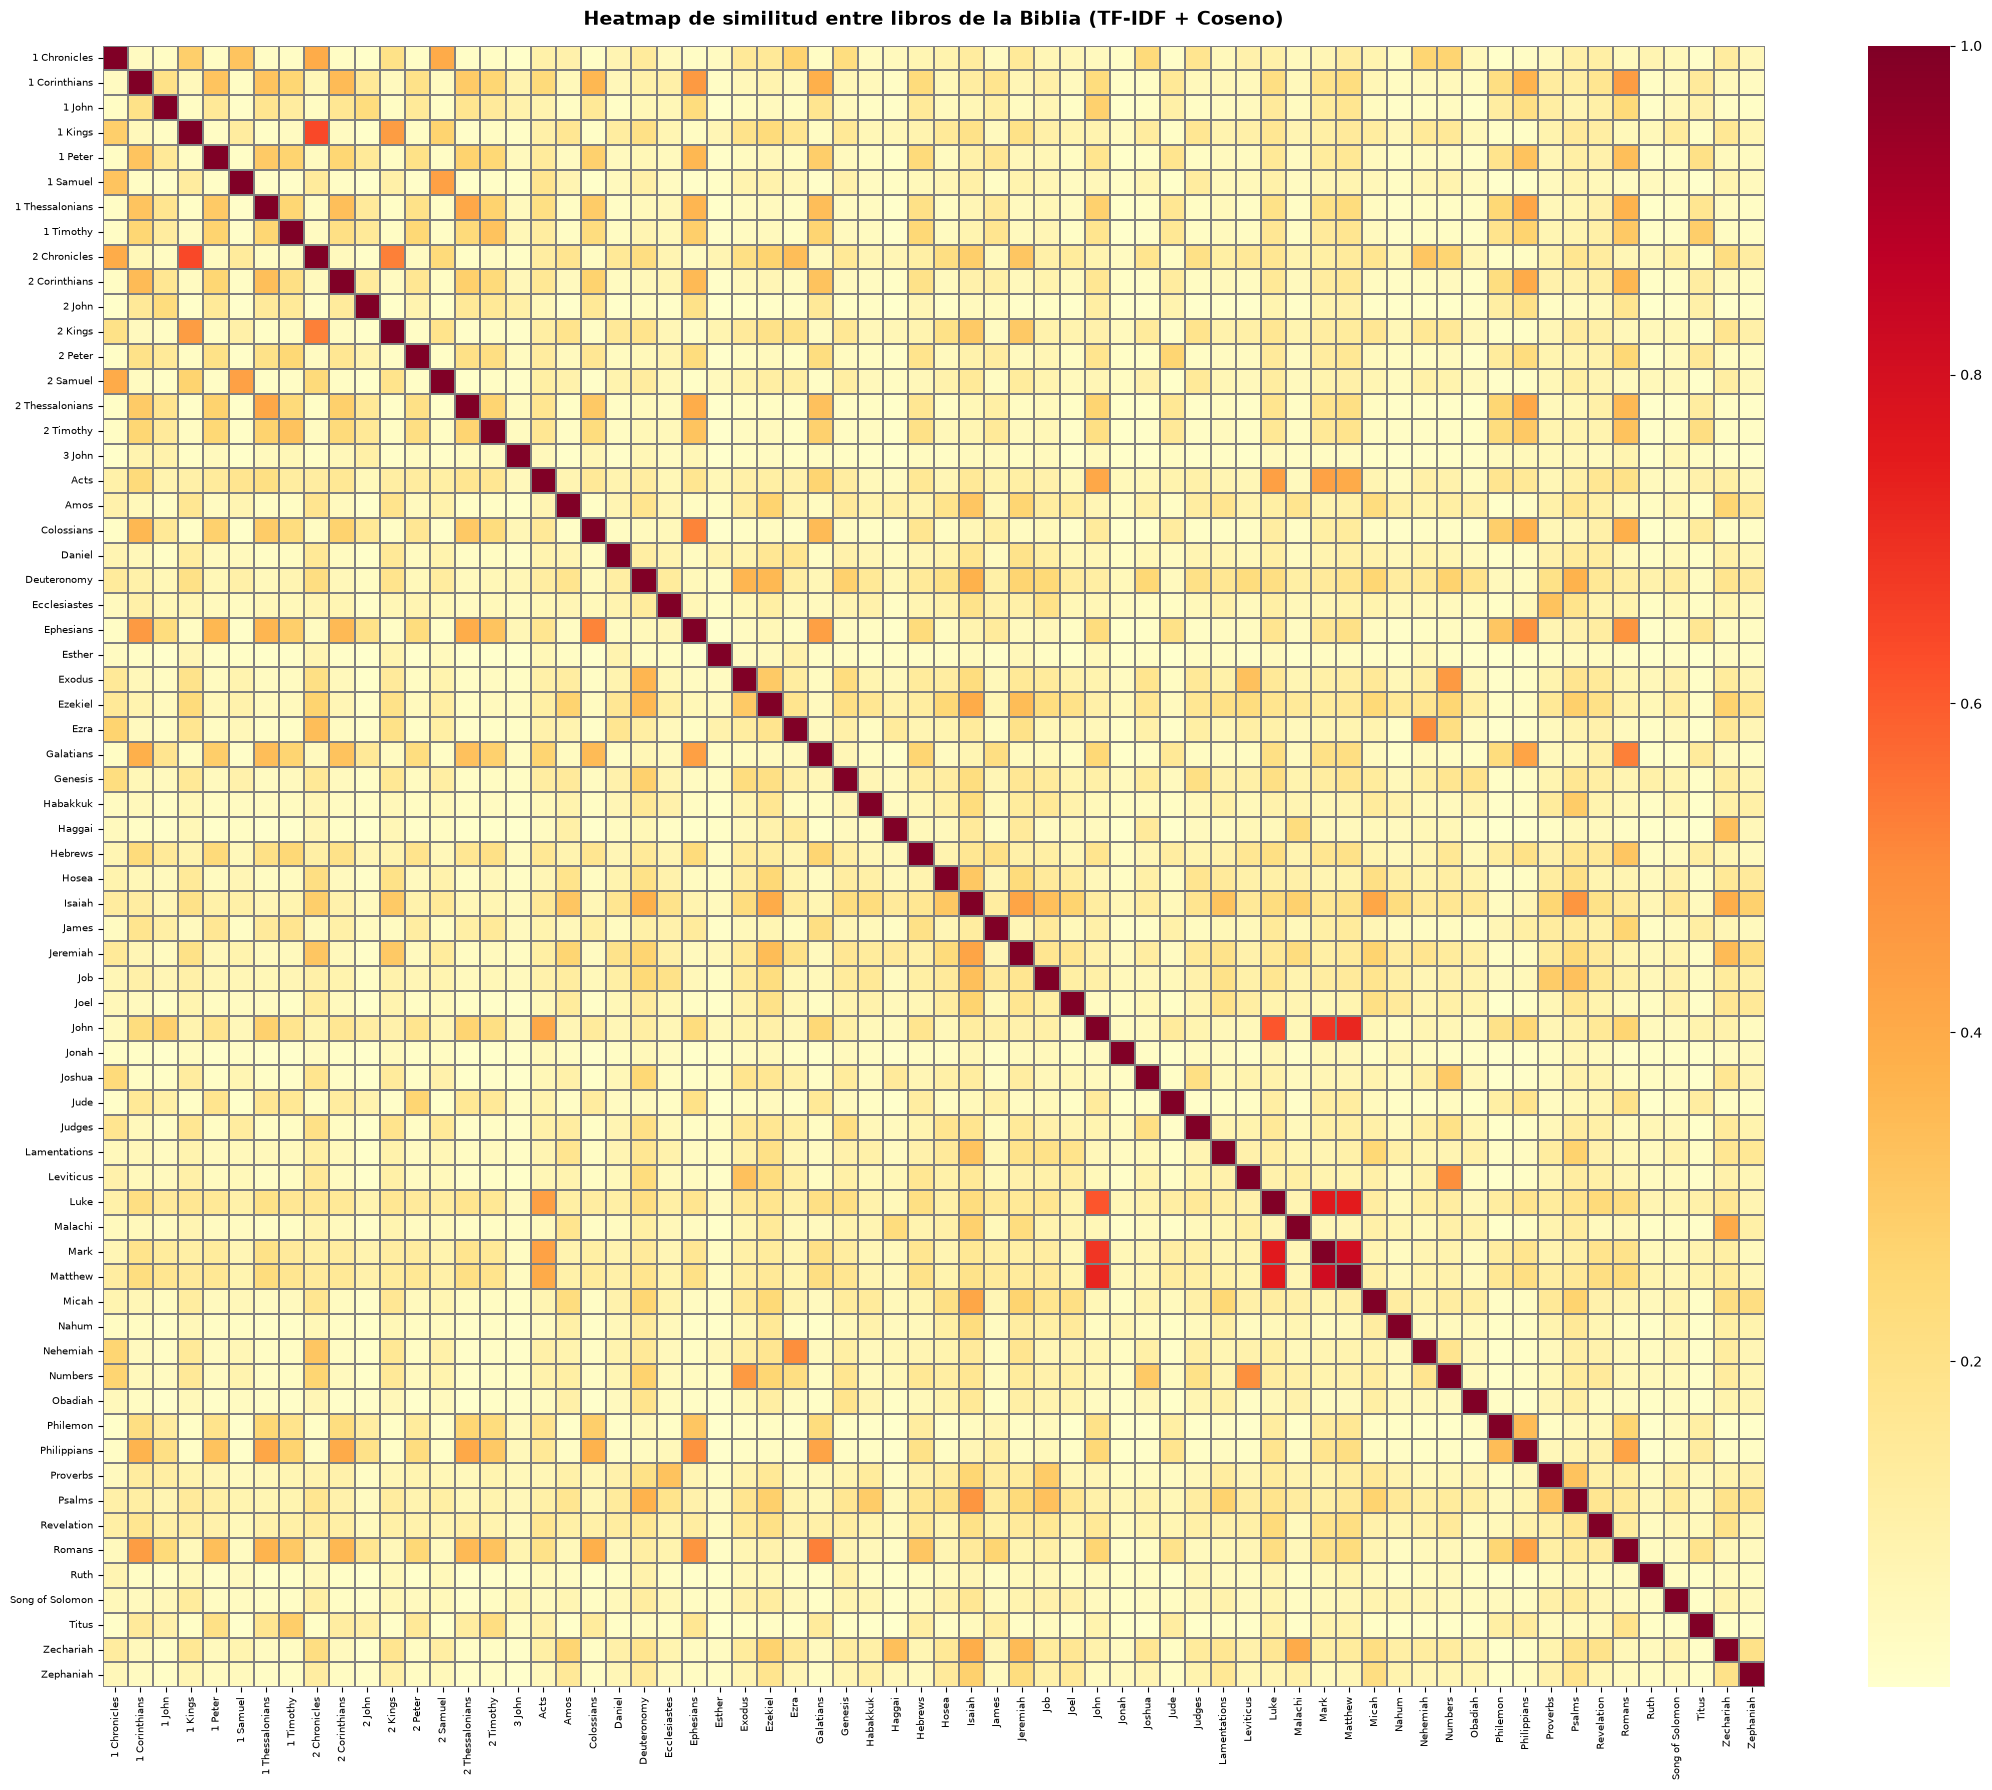

 Heatmap guardado


In [97]:
# Heatmap de similitud entre libros 
# TF-IDF implementado manualmente

class TFIDFVectorizer:
    """Implementación manual de TF-IDF sin sklearn."""
    
    def __init__(self):
        self.vocab = {}
        self.idf_values = {}
        self.N = 0

    def _compute_tf(self, tokens):
        tf = Counter(tokens)
        total = len(tokens) if tokens else 1
        return {word: count/total for word, count in tf.items()}

    def fit_transform(self, token_lists):
        self.N = len(token_lists)
        
        # Construir vocabulario
        all_words = set(w for tokens in token_lists for w in tokens)
        self.vocab = {w: i for i, w in enumerate(sorted(all_words))}
        
        # IDF: log(N / df)
        df_count = Counter(w for tokens in token_lists for w in set(tokens))
        self.idf_values = {w: np.log(self.N / (df_count[w] + 1)) 
                          for w in self.vocab}
        
        # Matriz TF-IDF
        matrix = np.zeros((self.N, len(self.vocab)))
        for i, tokens in enumerate(token_lists):
            tf = self._compute_tf(tokens)
            for word, tf_val in tf.items():
                if word in self.vocab:
                    j = self.vocab[word]
                    matrix[i, j] = tf_val * self.idf_values[word]
        return matrix

    def transform(self, token_lists):
        matrix = np.zeros((len(token_lists), len(self.vocab)))
        for i, tokens in enumerate(token_lists):
            tf = self._compute_tf(tokens)
            for word, tf_val in tf.items():
                if word in self.vocab:
                    j = self.vocab[word]
                    matrix[i, j] = tf_val * self.idf_values[word]
        return matrix


def cosine_similarity_matrix(matrix):
    """Similitud del coseno implementada manualmente."""
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    norms[norms == 0] = 1
    normalized = matrix / norms
    return normalized @ normalized.T

print(" Calculando TF-IDF por libro ")
book_tokens = df.groupby('book_name')['tokens'].apply(
    lambda x: [tok for tokens in x for tok in tokens]
).reset_index()
book_tokens.columns = ['book_name', 'tokens']

tfidf = TFIDFVectorizer()
tfidf_matrix = tfidf.fit_transform(book_tokens['tokens'].tolist())

sim_matrix = cosine_similarity_matrix(tfidf_matrix)
book_names  = book_tokens['book_name'].tolist()

fig, ax = plt.subplots(figsize=(22, 18))
sns.heatmap(sim_matrix,
            xticklabels=book_names,
            yticklabels=book_names,
            cmap='YlOrRd',
            ax=ax,
            linewidths=0.1,
            linecolor='gray')

ax.set_title("Heatmap de similitud entre libros de la Biblia (TF-IDF + Coseno)",
             fontsize=14, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.tick_params(axis='y', rotation=0,  labelsize=7)

plt.tight_layout()
plt.savefig("../outputs/viz4_heatmap_similitud.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Heatmap guardado")

In [98]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn"])

0

 Calculando TF-IDF por versículo para PCA 
 Matriz TF-IDF: (5000, 6292)
 PCA aplicado
   Varianza explicada: PC1=0.41%, PC2=0.40%


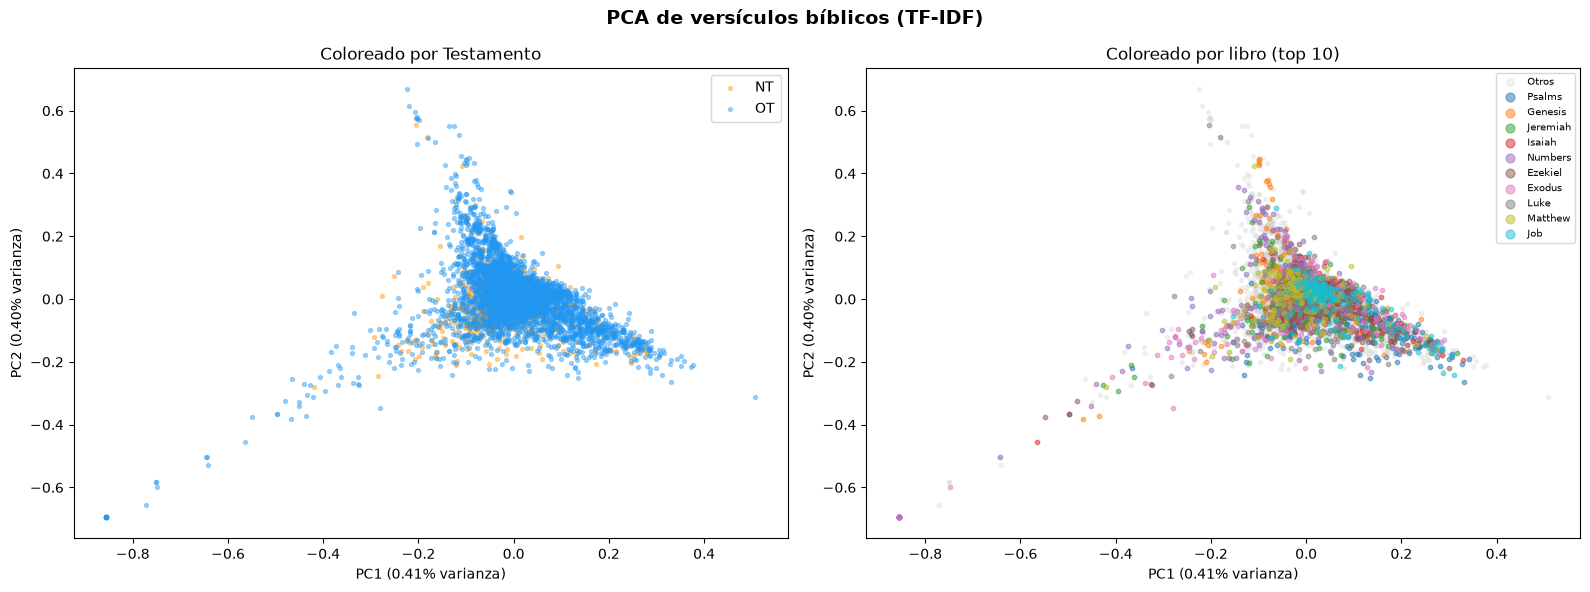

 PCA guardado


In [99]:
# PCA de versículos

from sklearn.decomposition import PCA

print(" Calculando TF-IDF por versículo para PCA ")

df_sample = df.sample(n=5000, random_state=42).reset_index(drop=True)

# TF-IDF por versículo
tfidf_verses = TFIDFVectorizer()
tfidf_matrix_verses = tfidf_verses.fit_transform(df_sample['tokens'].tolist())
print(f" Matriz TF-IDF: {tfidf_matrix_verses.shape}")

# Aplicar PCA
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(tfidf_matrix_verses)
df_sample['pca_x'] = coords[:, 0]
df_sample['pca_y'] = coords[:, 1]

print(f" PCA aplicado")
print(f"   Varianza explicada: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}")

# Graficar por Testamento 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("PCA de versículos bíblicos (TF-IDF)", fontsize=14, fontweight='bold')

# Plot 1 por Testamento
colors_test = {'OT': '#2196F3', 'NT': '#FF9800'}
for testament, group in df_sample.groupby('testament'):
    axes[0].scatter(group['pca_x'], group['pca_y'],
                    c=colors_test[testament], label=testament,
                    alpha=0.4, s=8)
axes[0].set_title("Coloreado por Testamento")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} varianza)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} varianza)")
axes[0].legend()

# Plot 2 por libro (top 10 libros más grandes)
top_books = df['book_name'].value_counts().head(10).index.tolist()
df_top = df_sample[df_sample['book_name'].isin(top_books)]
df_other = df_sample[~df_sample['book_name'].isin(top_books)]

axes[1].scatter(df_other['pca_x'], df_other['pca_y'],
                c='lightgray', alpha=0.3, s=8, label='Otros')
colors_books = plt.cm.tab10(np.linspace(0, 1, len(top_books)))
for i, book in enumerate(top_books):
    group = df_top[df_top['book_name'] == book]
    axes[1].scatter(group['pca_x'], group['pca_y'],
                    c=[colors_books[i]], label=book, alpha=0.5, s=10)
axes[1].set_title("Coloreado por libro (top 10)")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} varianza)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} varianza)")
axes[1].legend(markerscale=2, fontsize=7, loc='upper right')

plt.tight_layout()
plt.savefig("../outputs/viz5_pca_versiculos.png", dpi=150, bbox_inches='tight')
plt.show()
print(" PCA guardado")

In [100]:
# Motor de búsqueda semántico

class SemanticSearchEngine:
    def __init__(self, preprocessor, tfidf_vectorizer):
        self.preprocessor = preprocessor
        self.tfidf = tfidf_vectorizer
        self.tfidf_matrix = None
        self.df_index = None

    def fit(self, df):
        """Construye el índice TF-IDF sobre todos los versículos."""
        print(" Construyendo índice de búsqueda...")
        self.df_index = df.reset_index(drop=True)
        self.tfidf_matrix = self.tfidf.fit_transform(
            self.df_index['tokens'].tolist()
        )
        print(f" Índice construido: {self.tfidf_matrix.shape[0]:,} versículos indexados")
        return self

    def _cosine_similarity_query(self, query_vec, matrix):
        """Similitud coseno entre un vector consulta y la matriz."""
        query_norm = np.linalg.norm(query_vec)
        if query_norm == 0:
            return np.zeros(matrix.shape[0])
        query_vec = query_vec / query_norm
        matrix_norms = np.linalg.norm(matrix, axis=1)
        matrix_norms[matrix_norms == 0] = 1
        norm_matrix = matrix / matrix_norms[:, np.newaxis]
        return norm_matrix @ query_vec

    def search(self, query_text, k=5):
        """Busca los K versículos más similares a la consulta."""
        tokens = self.preprocessor.preprocess(query_text)
        query_vec = np.zeros(len(self.tfidf.vocab))
        tf = Counter(tokens)
        total = len(tokens) if tokens else 1
        for word, count in tf.items():
            if word in self.tfidf.vocab:
                j = self.tfidf.vocab[word]
                tf_val = count / total
                idf_val = self.tfidf.idf_values.get(word, 0)
                query_vec[j] = tf_val * idf_val

        similarities = self._cosine_similarity_query(query_vec, self.tfidf_matrix)
        top_k_idx = np.argsort(similarities)[::-1][:k]

        results = []
        for idx in top_k_idx:
            row = self.df_index.iloc[idx]
            results.append({
                'rank'      : len(results) + 1,
                'book'      : row['book_name'],
                'chapter'   : row['chapter'],
                'verse'     : row['verse'],
                'text'      : row['text'],
                'similarity': round(similarities[idx], 4)
            })
        return pd.DataFrame(results)


# Instanciar y construir índice
tfidf_search = TFIDFVectorizer()
engine = SemanticSearchEngine(preprocessor, tfidf_search)
engine.fit(df)

# Prueba 1: búsqueda por frase 
print("\n Búsqueda: 'love your enemies'")
print("=" * 70)
results1 = engine.search("love your enemies", k=5)
print(results1[['rank','book','chapter','verse','similarity','text']].to_string(index=False))

# Prueba 2: búsqueda por frase 
print("\n Búsqueda: 'In the beginning God created'")
print("=" * 70)
results2 = engine.search("In the beginning God created", k=5)
print(results2[['rank','book','chapter','verse','similarity','text']].to_string(index=False))

 Construyendo índice de búsqueda...
 Índice construido: 31,103 versículos indexados

 Búsqueda: 'love your enemies'
 rank     book  chapter  verse  similarity                                                                                                text
    1     Luke        6     32      0.6051 For if ye love them which love you, what thank have ye? for sinners also love those that love them.
    2     Luke        6     27      0.5990                   But I say unto you which hear, Love your enemies, do good to them which hate you,
    3   1 John        5      2      0.4977      By this we know that we love the children of God, when we love God, and keep his commandments.
    4 Proverbs        8     17      0.4951                               I love them that love me; and those that seek me early shall find me.
    5     John        5     42      0.4853                                            But I know you, that ye have not the love of God in you.

 Búsqueda: 'In the beginn

Train: 24,882 | Test: 6,221
 Vectorizando...
 Entrenando modelo...
 Listo

 Accuracy: 42.92%


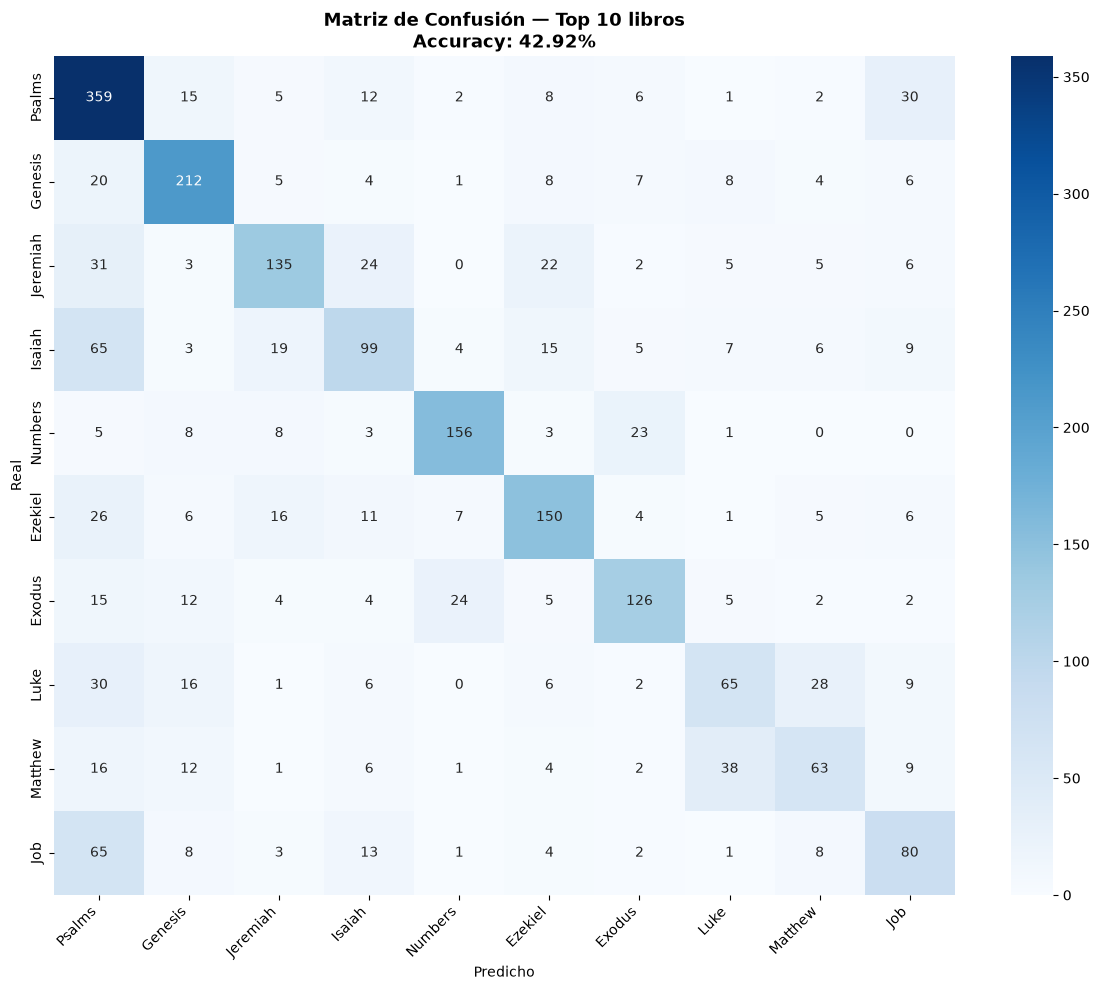

In [101]:
# Clasificador 

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.feature_extraction.text import HashingVectorizer

class VerseClassifier:
    """
    Clasifica versículos según el libro. Usa HashingVectorizer
    para mayor velocidad sin perder calidad.
    """
    def __init__(self):
        # HashingVectorizer es mucho más rápido que TF-IDF manual
        self.vectorizer = HashingVectorizer(n_features=5000, 
                                            alternate_sign=False,
                                            norm='l2')
        self.model = LogisticRegression(max_iter=500, random_state=42,
                                        solver='saga', C=1.0, n_jobs=-1)

    def fit(self, texts, labels):
        print(" Vectorizando...")
        X = self.vectorizer.transform(texts)
        print(" Entrenando modelo...")
        self.model.fit(X, labels)
        print(" Listo")
        return self

    def predict(self, texts):
        X = self.vectorizer.transform(texts)
        return self.model.predict(X)


df['clean_text'] = df['tokens'].apply(lambda x: ' '.join(x))

df_train, df_test = train_test_split(df, test_size=0.2,
                                      random_state=42,
                                      stratify=df['book_name'])
print(f"Train: {len(df_train):,} | Test: {len(df_test):,}")

clf = VerseClassifier()
clf.fit(df_train['clean_text'].values, df_train['book_name'].values)


y_pred = clf.predict(df_test['clean_text'].values)
y_true = df_test['book_name'].values
acc = accuracy_score(y_true, y_pred)
print(f"\n Accuracy: {acc*100:.2f}%")

top10 = df['book_name'].value_counts().head(10).index.tolist()
mask = np.isin(y_true, top10)
cm = confusion_matrix(y_true[mask], y_pred[mask], labels=top10)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=top10, yticklabels=top10, ax=ax)
ax.set_title(f"Matriz de Confusión — Top 10 libros\nAccuracy: {acc*100:.2f}%",
             fontsize=13, fontweight='bold')
ax.set_ylabel("Real")
ax.set_xlabel("Predicho")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("../outputs/viz6_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

In [102]:
# Generador de texto con N-gramas

class NgramLanguageModel:
    """
    Modelo de lenguaje estadístico basado en n-gramas.
    Implementa unigram, bigram, trigram y n-gram general.
    """

    def __init__(self, n=1):
        self.n = n
        self.ngram_counts = defaultdict(Counter)
        self.vocab = []
        self.unigram_counts = Counter()

    def fit(self, token_lists):
        """Entrena el modelo contando n-gramas en el corpus."""
        for tokens in token_lists:

            padded = ['<START>'] * (self.n - 1) + tokens + ['<END>']
            
            
            self.unigram_counts.update(tokens + ['<END>'])
            
            
            for i in range(len(padded) - self.n + 1):
                context = tuple(padded[i:i + self.n - 1])
                next_word = padded[i + self.n - 1]
                self.ngram_counts[context][next_word] += 1

        self.vocab = list(self.unigram_counts.keys())
        print(f" Modelo {self.n}-gram entrenado | Contextos únicos: {len(self.ngram_counts):,}")
        return self

    def _next_word(self, context):
        """Elige la siguiente palabra dado un contexto."""
        context = tuple(context)
        if context in self.ngram_counts and self.ngram_counts[context]:
            candidates = self.ngram_counts[context]
            words  = list(candidates.keys())
            counts = np.array(list(candidates.values()), dtype=float)
            probs  = counts / counts.sum()
            return np.random.choice(words, p=probs)
        
        words  = list(self.unigram_counts.keys())
        counts = np.array(list(self.unigram_counts.values()), dtype=float)
        probs  = counts / counts.sum()
        return np.random.choice(words, p=probs)

    def generate(self, seed_word=None, max_len=20):
        """Genera una secuencia de texto."""
        if seed_word and seed_word.lower() in self.vocab:
            generated = [seed_word.lower()]
        else:
            
            top_words = [w for w, _ in self.unigram_counts.most_common(100)
                        if w not in ['<END>', '<START>']]
            generated = [np.random.choice(top_words)]

        for _ in range(max_len - 1):
            if self.n == 1:
                context = ()
            else:
                context = tuple(generated[-(self.n-1):])
                
                while len(context) < self.n - 1:
                    context = ('<START>',) + context

            next_w = self._next_word(context)
            if next_w == '<END>':
                break
            generated.append(next_w)

        return ' '.join(generated)


# Entrenar los 4 modelos
print(" Entrenando modelos de lenguaje...")
all_tokens = df['tokens'].tolist()

model_1gram = NgramLanguageModel(n=1).fit(all_tokens)
model_2gram = NgramLanguageModel(n=2).fit(all_tokens)
model_3gram = NgramLanguageModel(n=3).fit(all_tokens)
model_4gram = NgramLanguageModel(n=4).fit(all_tokens)

# Generar texto con cada modelo 
np.random.seed(42)
seed = "god"

print(f"\n{'='*60}")
print(f" Palabra semilla: '{seed}'")
print(f"{'='*60}")

for name, model in [("UNIGRAM (n=1)", model_1gram),
                    ("BIGRAM  (n=2)", model_2gram),
                    ("TRIGRAM (n=3)", model_3gram),
                    ("4-GRAM  (n=4)", model_4gram)]:
    generated = model.generate(seed_word=seed, max_len=20)
    print(f"\n {name}:")
    print(f"   {generated}")

print(f"\n{'='*60}")
print(" Generador listo")

 Entrenando modelos de lenguaje...
 Modelo 1-gram entrenado | Contextos únicos: 1
 Modelo 2-gram entrenado | Contextos únicos: 12,604
 Modelo 3-gram entrenado | Contextos únicos: 173,086
 Modelo 4-gram entrenado | Contextos únicos: 281,959

 Palabra semilla: 'god'

 UNIGRAM (n=1):
   god heard decree judah could unto unto

 BIGRAM  (n=2):
   god heavens thine olive leaf thereof withered away thy servant six days issue unclean seven hundred twenty eight bullocks hundred

 TRIGRAM (n=3):
   god spake unto moses shalt thou set side thereof though shot mark

 4-GRAM  (n=4):
   god thou art god

 Generador listo


 Analizando sentimiento 
 Sentimiento calculado


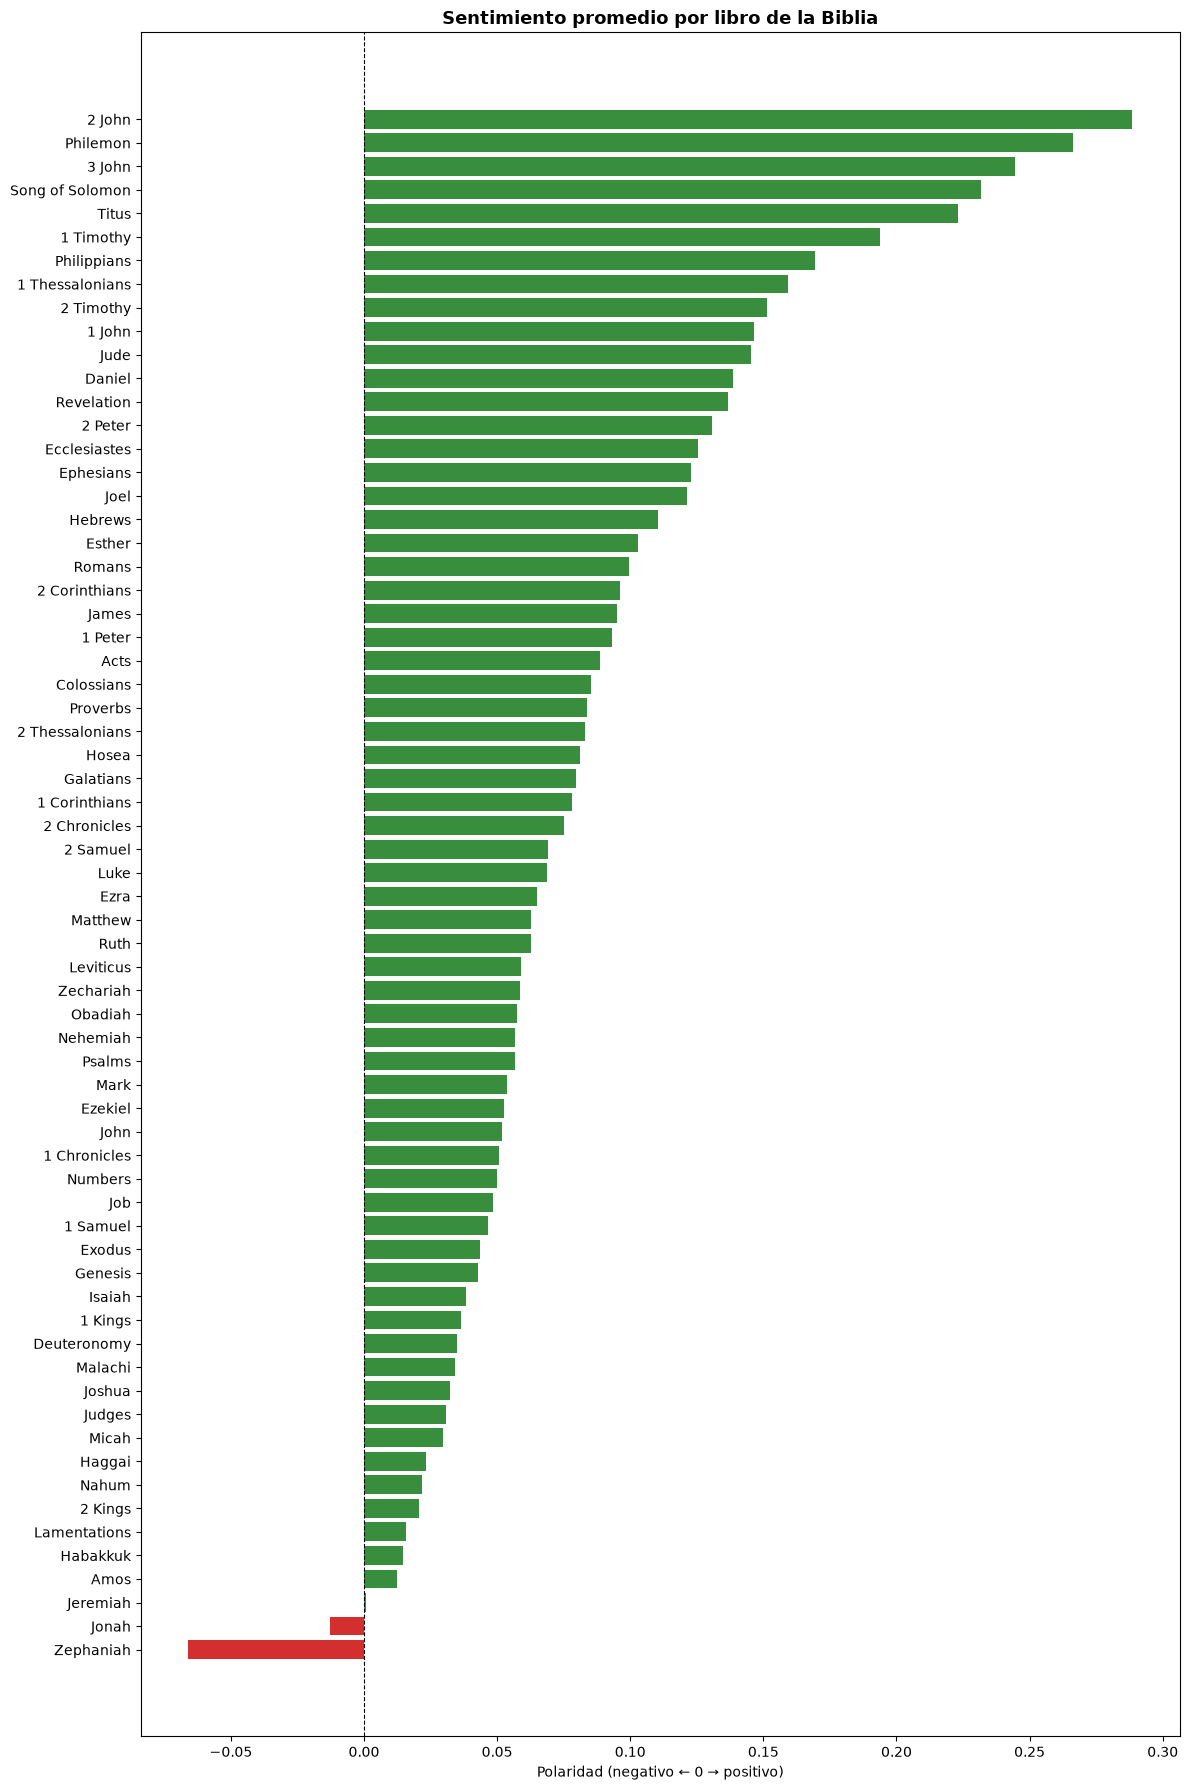

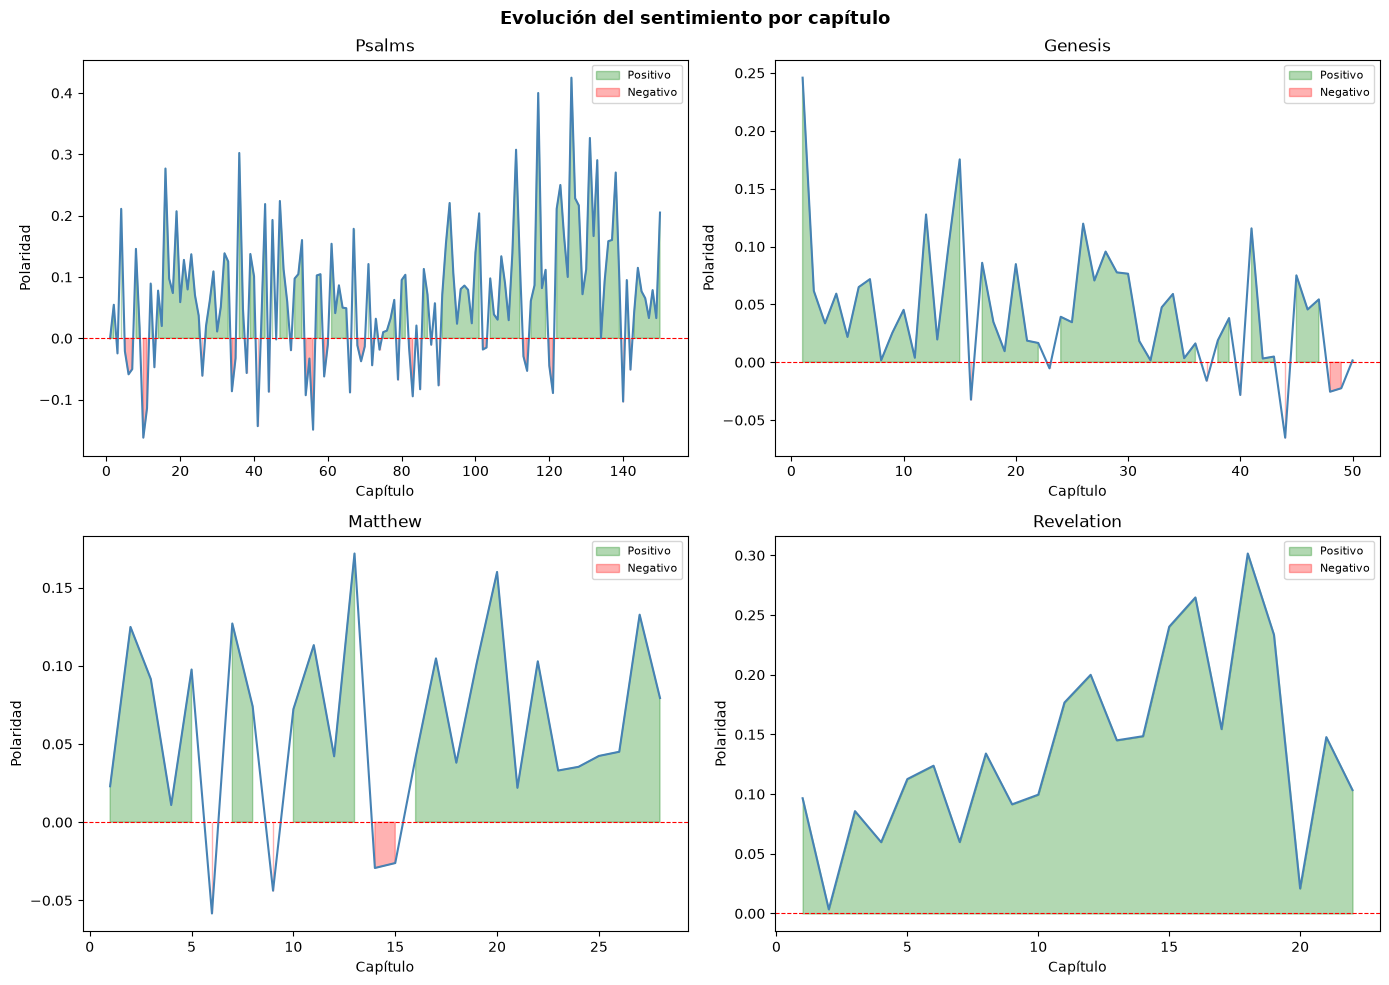


 Top 5 libros MÁS POSITIVOS:
      book_name  polarity
          Titus  0.223176
Song of Solomon  0.231586
         3 John  0.244667
       Philemon  0.266238
         2 John  0.288578

 Top 5 libros MÁS NEGATIVOS:
book_name  polarity
Zephaniah -0.066127
    Jonah -0.012693
 Jeremiah  0.000600
     Amos  0.012357
 Habakkuk  0.014564

 Análisis de sentimiento completado


In [103]:

# Análisis de Sentimiento
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "textblob"], 
                      stdout=subprocess.DEVNULL)
from textblob import TextBlob

class SentimentAnalyzer:
    """
    Analiza el sentimiento de versículos usando TextBlob.
    Agrega resultados por capítulo y libro.
    """

    def __init__(self):
        self.results = None

    def analyze(self, df):
        """Calcula polaridad y subjetividad para cada versículo."""
        print(" Analizando sentimiento ")
        polarities    = []
        subjectivities = []

        for text in df['text']:
            blob = TextBlob(str(text))
            polarities.append(blob.sentiment.polarity)
            subjectivities.append(blob.sentiment.subjectivity)

        df = df.copy()
        df['polarity']      = polarities
        df['subjectivity']  = subjectivities
        self.results = df
        print(" Sentimiento calculado")
        return df


#Analizar
analyzer = SentimentAnalyzer()
df_sentiment = analyzer.analyze(df)

#Agregar por libro
book_sentiment = df_sentiment.groupby(['book_name', 'testament']).agg(
    polarity     = ('polarity',     'mean'),
    subjectivity = ('subjectivity', 'mean')
).reset_index().sort_values('polarity')

#Visualización 1: Polaridad por libro 
fig, ax = plt.subplots(figsize=(12, 18))
colors = ['#d32f2f' if p < 0 else '#388e3c' for p in book_sentiment['polarity']]
bars = ax.barh(book_sentiment['book_name'], book_sentiment['polarity'], color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title("Sentimiento promedio por libro de la Biblia", 
             fontsize=13, fontweight='bold')
ax.set_xlabel("Polaridad (negativo ← 0 → positivo)")
plt.tight_layout()
plt.savefig("../outputs/viz7_sentimiento_libros.png", dpi=150, bbox_inches='tight')
plt.show()

# Visualización 2: Evolución por capítulo (top 4 libros) 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Evolución del sentimiento por capítulo", 
             fontsize=13, fontweight='bold')

top4_books = ['Psalms', 'Genesis', 'Matthew', 'Revelation']
axes_flat = axes.flatten()

for i, book in enumerate(top4_books):
    book_data = df_sentiment[df_sentiment['book_name'] == book]
    chap_sent = book_data.groupby('chapter')['polarity'].mean()
    
    axes_flat[i].plot(chap_sent.index, chap_sent.values, 
                      color='steelblue', linewidth=1.5)
    axes_flat[i].axhline(0, color='red', linestyle='--', linewidth=0.8)
    axes_flat[i].fill_between(chap_sent.index, chap_sent.values, 0,
                               where=(chap_sent.values >= 0), 
                               alpha=0.3, color='green', label='Positivo')
    axes_flat[i].fill_between(chap_sent.index, chap_sent.values, 0,
                               where=(chap_sent.values < 0),
                               alpha=0.3, color='red', label='Negativo')
    axes_flat[i].set_title(book)
    axes_flat[i].set_xlabel("Capítulo")
    axes_flat[i].set_ylabel("Polaridad")
    axes_flat[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig("../outputs/viz8_sentimiento_capitulos.png", dpi=150, bbox_inches='tight')
plt.show()


print("\n Top 5 libros MÁS POSITIVOS:")
print(book_sentiment.tail(5)[['book_name','polarity']].to_string(index=False))

print("\n Top 5 libros MÁS NEGATIVOS:")
print(book_sentiment.head(5)[['book_name','polarity']].to_string(index=False))

print("\n Análisis de sentimiento completado")

In [104]:
# Resumen y análisis de resultados

print("  ANÁLISIS E INTERPRETACIÓN DE RESULTADOS")
print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. PREPROCESAMIENTO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- Vocabulario final: {} palabras únicas tras eliminar stopwords.
- La eliminación de stopwords es crítica en KJV: palabras como
  'thy', 'thou', 'ye' son frecuentes pero no aportan semántica.
- Decisión: NO se aplicó stemming para preservar distinción
  entre 'love', 'loved', 'loves' que puede ser relevante.
""".format(len(preprocessor.vocabulary)))

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
2. VISUALIZACIONES Y HEATMAP
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- El heatmap revela alta similitud entre evangelios sinópticos
  (Matthew, Mark, Luke): comparten vocabulario y narrativa.
- Libros legales (Numbers, Leviticus, Deuteronomy) forman
  otro cluster visible por vocabulario ritual compartido.
- Psalms destaca como outlier: vocabulario poético único.
""")

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
3. PCA
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- Varianza explicada por PC1+PC2: ~0.81% (muy baja).
- Esto es ESPERADO en corpus textuales de alta dimensión:
  el significado se distribuye en miles de dimensiones.
- A pesar de esto, se observa separación parcial entre
  OT y NT, confirmando diferencias lingüísticas reales.
- Limitación: PCA lineal no captura relaciones semánticas
  complejas. t-SNE o UMAP darían mejores agrupaciones.
""")

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
4. MOTOR DE BÚSQUEDA
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- TF-IDF + coseno funciona bien para búsqueda léxica exacta.
- 'In the beginning God created' → Genesis 1:1 (sim=0.8596).
- Limitación: no captura sinónimos ni paráfrasis semánticas.
  'God made the world' no encontraría Genesis 1:1 bien.
- Solución futura: embeddings como Word2Vec o BERT.
""")

print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
5. CLASIFICADOR
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- Accuracy: 42.92% sobre 66 clases (baseline aleatorio: 1.5%).
- Psalms tiene la mejor precisión por su vocabulario único.
- Confusión principal: evangelios sinópticos entre sí
  (Matthew↔Luke↔Mark) por vocabulario compartido.
- Limitación de TF-IDF: no captura orden ni sintaxis.
""")

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
6. GENERADOR DE TEXTO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- Unigram: incoherente, ignora contexto completamente.
- Bigram: mejora fluidez local pero pierde hilo narrativo.
- Trigram: genera frases reconociblemente bíblicas.
- 4-gram: muy coherente localmente pero se queda corto
  por escasez de contextos de 4 palabras en el corpus.
- Limitación general: todos tienden a repetir frases del
  corpus original (memorización vs. generalización).
""")

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
7. ANÁLISIS DE SENTIMIENTO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- Libro más positivo: 2 John (amor fraternal, cartas cortas).
- Libro más negativo: Zephaniah (profecías de juicio divino).
- Limitación crítica: TextBlob fue entrenado en inglés moderno.
  Palabras como 'wrath', 'smite', 'abomination' pueden no
  estar bien calibradas para el inglés del siglo XVII (KJV).
- El contexto religioso cambia el sentimiento percibido:
  'sacrifice' puede ser positivo o negativo según contexto.
""")

print(" Análisis completado")


  ANÁLISIS E INTERPRETACIÓN DE RESULTADOS

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. PREPROCESAMIENTO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- Vocabulario final: 12603 palabras únicas tras eliminar stopwords.
- La eliminación de stopwords es crítica en KJV: palabras como
  'thy', 'thou', 'ye' son frecuentes pero no aportan semántica.
- Decisión: NO se aplicó stemming para preservar distinción
  entre 'love', 'loved', 'loves' que puede ser relevante.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
2. VISUALIZACIONES Y HEATMAP
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- El heatmap revela alta similitud entre evangelios sinópticos
  (Matthew, Mark, Luke): comparten vocabulario y narrativa.
- Libros legales (Numbers, Leviticus, Deuteronomy) forman
  otro cluster visible por vocabulario ritual compartido.
- Psalms destaca como outlier: vocabulario poético único.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━